# 04 V3 — LightGBM: PR AUC Objective + Instance Weighting

## V3 Changes vs V2
| | V2 | V3 |
|---|---|---|
| Optuna objective | ROC AUC | **PR AUC** |
| Training weights | None | **4 temporal chunks [1,2,3,4]** |
| Params file | best_params_lgbm.json | **best_params_lgbm_v3.json** |
| XGBoost | ✅ | ❌ skipped (architectural limitation) |
| Ensemble | ✅ | ❌ skipped (no new XGBoost) |

## Goal
Test whether optimizing directly for PR AUC + temporal instance weighting
improves fraud detection quality over V2 (ROC AUC optimized, no weights).

**This notebook is a pure orchestrator — all logic lives in src/ modules.**

## Inputs (same as V2 — no reprocessing needed)
```
outputs/preproc/X_train_lgbm.parquet  — 354,324 rows × 460 features
outputs/preproc/X_val_lgbm.parquet    — 118,108 rows × 460 features
outputs/preproc/X_test_lgbm.parquet   — 118,108 rows × 460 features (frozen)
outputs/preproc/y_train.parquet
outputs/preproc/y_val.parquet
outputs/preproc/y_test.parquet
```

## Outputs
```
outputs/best_params_lgbm_v3.json      — V3 Optuna best params (PR AUC)
outputs/models/model_lgbm_v3.pkl      — V3 trained model
```

## Reference Results (Test — unbiased)
```
Statistical Baseline: PR AUC = 0.035 (predict all legitimate)
V2 LightGBM:  Test ROC 0.8974  Test PR 0.5087  ← V3 target to beat
```

## Step 1 — Imports & Setup

In [1]:
import sys, os, pickle, warnings
warnings.filterwarnings('ignore')

# Notebook lives in v3/ — go one level up to reach project root
PROJECT_ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
for subdir in ['', 'src', 'v0']:
    p = os.path.join(PROJECT_ROOT_PATH, subdir)
    if p not in sys.path:
        sys.path.insert(0, p)

from config import PROJECT_ROOT, PREPROC_DIR, OUTPUTS_DIR
from pipeline_evaluate import load_splits, evaluate_model
from preproc_weights import compute_sample_weights
from tune_optuna_v3 import tune_lgbm_v3
from train_lgbm_v3 import train_lgbm_v3

MODELS_DIR = OUTPUTS_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Statistical baseline — predict all legitimate
STAT_BASELINE_PR = 0.035

# V2 reference — V3 must beat this
V2_TEST_ROC = 0.8974
V2_TEST_PR  = 0.5087

# Flags
RUN_OPTUNA   = False   # Set False to skip Optuna and use saved params
RETRAIN      = False   # Set False to load saved model

PARAM_PATH   = OUTPUTS_DIR / 'best_params_lgbm_v3.json'
MODEL_PATH   = MODELS_DIR  / 'model_lgbm_v3.pkl'

print(f'Project root : {PROJECT_ROOT}')
print(f'Preproc dir  : {PREPROC_DIR}')
print(f'Models dir   : {MODELS_DIR}')
print(f'RUN_OPTUNA   : {RUN_OPTUNA}')
print(f'RETRAIN      : {RETRAIN}')

Project root : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection
Preproc dir  : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\preproc
Models dir   : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models
RUN_OPTUNA   : False
RETRAIN      : False


## Step 2 — Load Preprocessed Splits

In [2]:
X_train, X_val, X_test, encoding_map, y_train, y_val, y_test = load_splits(PREPROC_DIR)

STEP 1 — Load preprocessed splits
   X_train_lgbm : (354324, 460)  | fraud rate: 3.3833%
   X_val_lgbm   : (118108, 460)    | fraud rate: 3.9041%  (early stopping)
   X_test_lgbm  : (118108, 460)   | fraud rate: 3.4409%  (frozen TEST)
   encoding_map : 32 encoders


## Step 3 — Compute Instance Weights

Assign weights based on temporal chunks — applied to train only.
```
days 1–25:   weight=1.0  (oldest)
days 26–50:  weight=2.0
days 51–75:  weight=3.0
days 76–101: weight=4.0  (most recent, closest to val period)
```

In [3]:
sample_weight = compute_sample_weights(X_train, time_col='tx_day')

SAMPLE WEIGHTS — Temporal Chunk Weighting
   Time column : tx_day
   Chunks      : 4
     Chunk 1: days   1– 25  →  weight=1.0
     Chunk 2: days  26– 50  →  weight=2.0
     Chunk 3: days  51– 75  →  weight=3.0
     Chunk 4: days  76–101  →  weight=4.0

   Weight distribution:
     weight=1.0 : 116,291 rows (32.8%)
     weight=2.0 :  79,733 rows (22.5%)
     weight=3.0 :  74,882 rows (21.1%)
     weight=4.0 :  83,418 rows (23.5%)

   Coverage: all 354,324 rows assigned ✓


## Step 4 — Optuna Tuning (PR AUC Objective)

In [4]:
if RUN_OPTUNA:
    best_params = tune_lgbm_v3(
        X_train, y_train,
        X_val,   y_val,
        sample_weight = sample_weight,
        quality       = 'med_high',
        save_path     = str(PARAM_PATH),
    )
else:
    print(f'RUN_OPTUNA=False — using saved params from {PARAM_PATH}')

RUN_OPTUNA=False — using saved params from C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\best_params_lgbm_v3.json


## Step 5 — Train LightGBM V3

In [5]:
if RETRAIN or not MODEL_PATH.exists():
    model_lgbm_v3, y_pred_val = train_lgbm_v3(
        X_train, y_train,
        X_val,   y_val,
        sample_weight = sample_weight,
        params_path   = str(PARAM_PATH),
        # models_dir    = MODELS_DIR,
    )
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(model_lgbm_v3, f)
    print(f'Model saved → {MODEL_PATH}')
else:
    with open(MODEL_PATH, 'rb') as f:
        model_lgbm_v3 = pickle.load(f)
    y_pred_val = model_lgbm_v3.predict_proba(X_val)[:, 1].astype('float32')
    print(f'Loaded model_lgbm_v3 ← {MODEL_PATH}')

Loaded model_lgbm_v3 ← C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_lgbm_v3.pkl


## Step 6 — Evaluate on Val (informational)

  Model                 ROC AUC    PR AUC
  statistical baseline        —    0.0350
  LightGBM V3 (PR AUC + Weights)   0.9241    0.6470   Δ PR=+0.6120


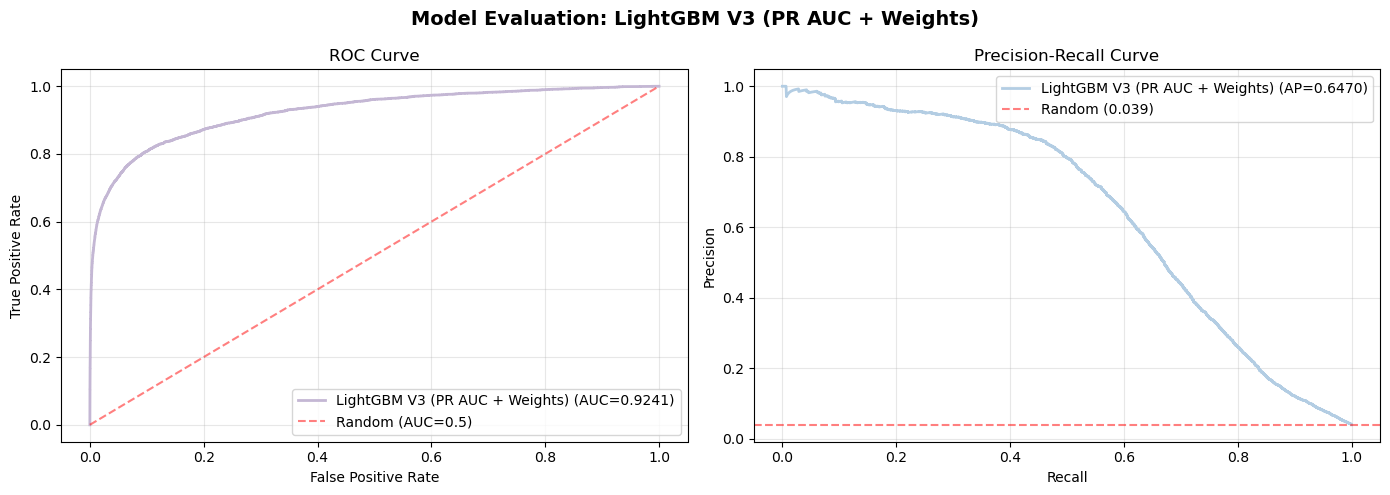

>> Top 30 features by importance:
     1. card1                           importance: 22793
     2. tx_day                          importance: 19103
     3. card2                           importance: 16822
     4. amt_vs_product_median           importance: 16307
     5. TransactionAmt                  importance: 14001
     6. tx_dom                          importance: 12276
     7. addr1                           importance: 11973
     8. tx_hour                         importance: 9689
     9. hour_vs_typical                 importance: 8736
    10. time_since_last_tx              importance: 8204
    11. delta_amt                       importance: 7893
    12. tx_amt_mean                     importance: 7549
    13. tx_amt_max                      importance: 7353
    14. tx_amt_std                      importance: 6731
    15. id_02                           importance: 6699
    16. P_emaildomain                   importance: 6560
    17. tx_amt_min                      importa

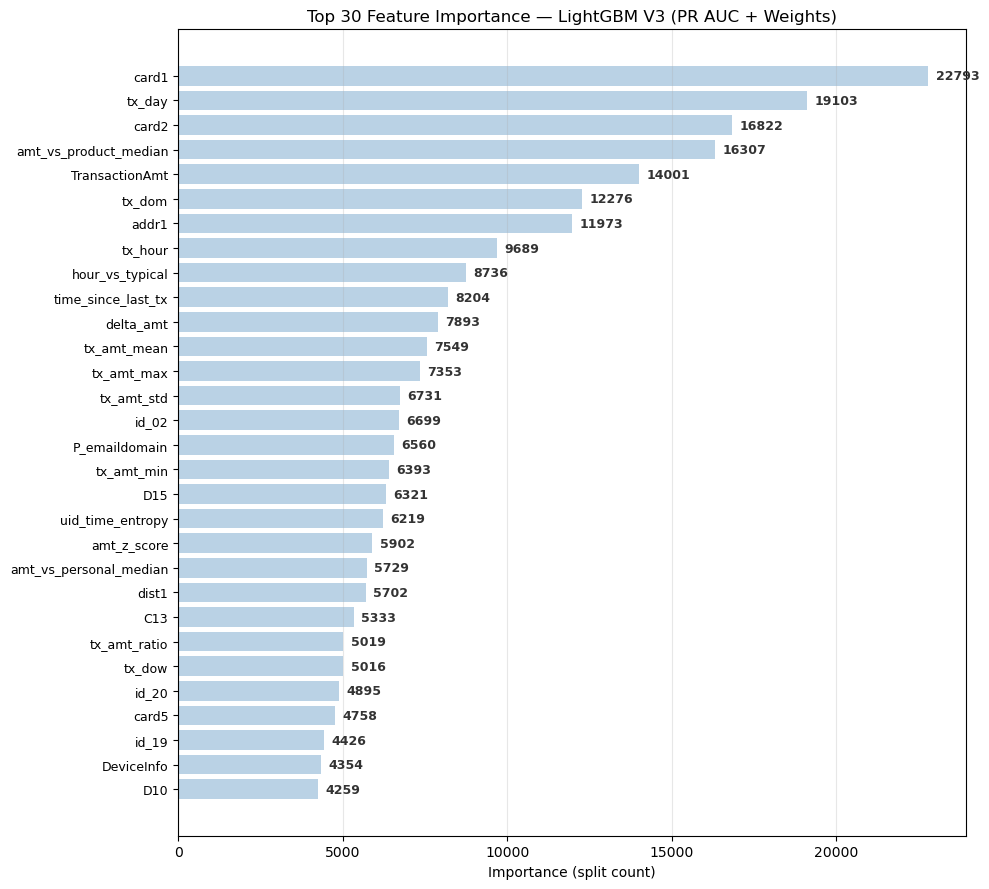

In [6]:
val_roc, val_pr = evaluate_model(
    y_val, y_pred_val,
    model_name    = 'LightGBM V3 (PR AUC + Weights)',
    v0_roc        = None,
    v0_pr         = STAT_BASELINE_PR,
    model         = model_lgbm_v3,
    feature_names = X_val.columns.tolist(),
    show_plot     = True,
)

## Step 7 — Predict on Frozen TEST

In [7]:
y_pred_test = model_lgbm_v3.predict_proba(X_test)[:, 1].astype('float32')

## Step 8 — Evaluate on Frozen TEST

> ⚠️ **Primary comparison — Test metrics are the only unbiased evaluation.**
> Val metrics are influenced by Optuna tuning and cannot be used as final comparison.

  Model                 ROC AUC    PR AUC
  statistical baseline        —    0.0350
  LightGBM V3 (PR AUC + Weights)   0.8904    0.5142   Δ PR=+0.4792


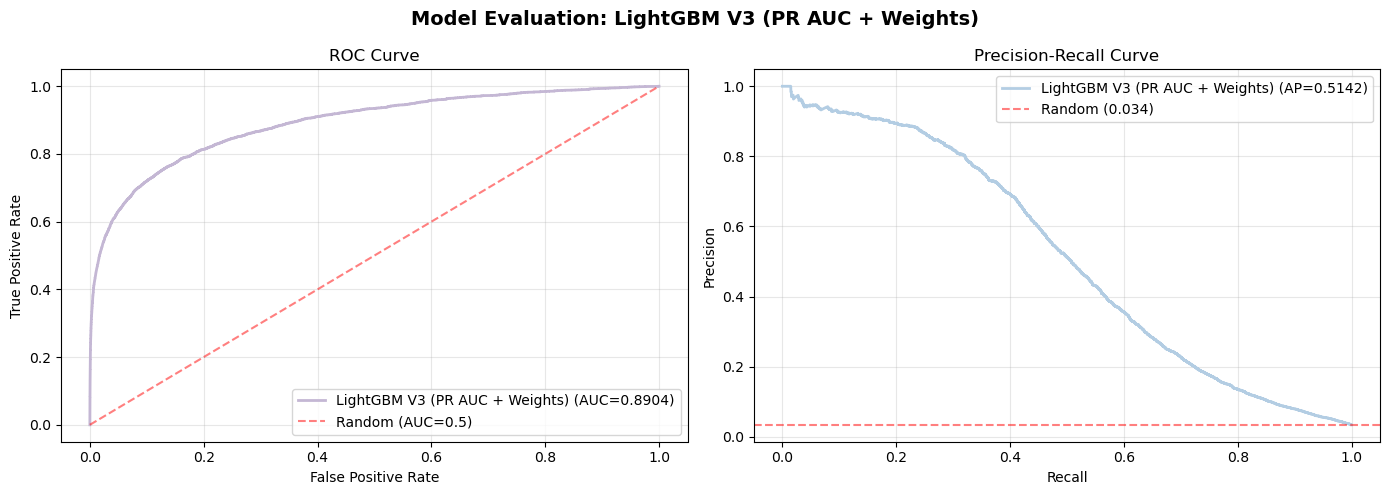

In [8]:
test_roc, test_pr = evaluate_model(
    y_test, y_pred_test,
    model_name = 'LightGBM V3 (PR AUC + Weights)',
    v0_roc     = None,
    v0_pr      = STAT_BASELINE_PR,
    show_plot  = True,
)

## Step 9 — Final Comparison Table

In [9]:
print('=' * 70)
print('FINAL COMPARISON — V2 vs V3 vs Statistical Baseline')
print('=' * 70)
print(f"  {'Model':<35} {'Test ROC':>9} {'Test PR':>9} {'×Baseline':>10}")
print(f"  {'─'*67}")
print(f"  {'Statistical Baseline (all legit)':<35} {'—':>9} {STAT_BASELINE_PR:>9.3f} {'1.0×':>10}")
print(f"  {'V2 LightGBM (ROC AUC, no weights)':<35} {V2_TEST_ROC:>9.4f} {V2_TEST_PR:>9.4f} {V2_TEST_PR/STAT_BASELINE_PR:>9.1f}×")
print(f"  {'V3 LightGBM (PR AUC + weights)':<35} {test_roc:>9.4f} {test_pr:>9.4f} {test_pr/STAT_BASELINE_PR:>9.1f}×")
print('=' * 70)

print('\nConclusion:')
if test_pr > V2_TEST_PR:
    print(f'  ✅ V3 improves Test PR AUC: {V2_TEST_PR:.4f} → {test_pr:.4f} (+{test_pr-V2_TEST_PR:.4f})')
else:
    print(f'  ❌ V3 does NOT improve Test PR AUC: {V2_TEST_PR:.4f} → {test_pr:.4f} ({test_pr-V2_TEST_PR:+.4f})')

if test_roc > V2_TEST_ROC:
    print(f'  ✅ V3 improves Test ROC AUC: {V2_TEST_ROC:.4f} → {test_roc:.4f} (+{test_roc-V2_TEST_ROC:.4f})')
else:
    print(f'  ❌ V3 does NOT improve Test ROC AUC: {V2_TEST_ROC:.4f} → {test_roc:.4f} ({test_roc-V2_TEST_ROC:+.4f})')

FINAL COMPARISON — V2 vs V3 vs Statistical Baseline
  Model                                Test ROC   Test PR  ×Baseline
  ───────────────────────────────────────────────────────────────────
  Statistical Baseline (all legit)            —     0.035       1.0×
  V2 LightGBM (ROC AUC, no weights)      0.8974    0.5087      14.5×
  V3 LightGBM (PR AUC + weights)         0.8904    0.5142      14.7×

Conclusion:
  ✅ V3 improves Test PR AUC: 0.5087 → 0.5142 (+0.0055)
  ❌ V3 does NOT improve Test ROC AUC: 0.8974 → 0.8904 (-0.0070)


# Step 10 — Ensemble V2 + V3 (Average Probabilities)

In [10]:
import pickle
from pathlib import Path

# Load V2 model
model_v2_path = MODELS_DIR / 'model_lgbm.pkl'
with open(model_v2_path, 'rb') as f:
    model_lgbm_v2 = pickle.load(f)

# V2 predictions (no weights — standard model)
y_pred_val_v2  = model_lgbm_v2.predict_proba(X_val)[:, 1].astype('float32')
y_pred_test_v2 = model_lgbm_v2.predict_proba(X_test)[:, 1].astype('float32')

# V3 predictions (already computed above)
# y_pred_val  → from Step 5
# y_pred_test → from Step 7

# Ensemble: simple average
y_pred_val_ens  = (y_pred_val_v2  + y_pred_val)  / 2
y_pred_test_ens = (y_pred_test_v2 + y_pred_test) / 2

print('Ensemble V2 + V3 predictions computed ✓')

Ensemble V2 + V3 predictions computed ✓


# Step 11 — Evaluate Ensemble on Val + Test

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

ens_val_roc  = roc_auc_score(y_val,  y_pred_val_ens)
ens_val_pr   = average_precision_score(y_val,  y_pred_val_ens)
ens_test_roc = roc_auc_score(y_test, y_pred_test_ens)
ens_test_pr  = average_precision_score(y_test, y_pred_test_ens)

print('=' * 70)
print('ENSEMBLE V2 + V3 — Val + Test Metrics')
print('=' * 70)
print(f"  {'Model':<40} {'Val ROC':>8} {'Val PR':>8} {'Test ROC':>9} {'Test PR':>8}")
print(f"  {'─'*67}")
print(f"  {'Statistical Baseline (all legit)':<40} {'—':>8} {'—':>8} {'—':>9} {STAT_BASELINE_PR:>8.3f}")
print(f"  {'V2 LightGBM (ROC AUC, no weights)':<40} {'0.9327':>8} {'0.6281':>8} {V2_TEST_ROC:>9.4f} {V2_TEST_PR:>8.4f}")
print(f"  {'V3 LightGBM (PR AUC + weights)':<40} {val_roc:>8.4f} {val_pr:>8.4f} {test_roc:>9.4f} {test_pr:>8.4f}")
print(f"  {'Ensemble V2 + V3':<40} {ens_val_roc:>8.4f} {ens_val_pr:>8.4f} {ens_test_roc:>9.4f} {ens_test_pr:>8.4f}")
print('=' * 70)

ENSEMBLE V2 + V3 — Val + Test Metrics
  Model                                     Val ROC   Val PR  Test ROC  Test PR
  ───────────────────────────────────────────────────────────────────
  Statistical Baseline (all legit)                —        —         —    0.035
  V2 LightGBM (ROC AUC, no weights)          0.9327   0.6281    0.8974   0.5087
  V3 LightGBM (PR AUC + weights)             0.9241   0.6470    0.8904   0.5142
  Ensemble V2 + V3                           0.9342   0.6440    0.8990   0.5178
